# 04 Cell Annotation

Use the marker-gene workflow from the tutorial's Notebook 5, but keep annotation focused on confirming that this dataset is CD8 T cells and saving a CD8-annotated object for downstream state annotation.

In [1]:
import sys
sys.path.append("/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025")

import numpy as np
import pandas as pd
import scanpy as sc

from src.paths import INTERMEDIATE_DIR, RESULTS_DIR

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor="white")


/tmp/ipykernel_3777537/2434692184.py:11: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white")


## Load Clustered Data

Start from the combined clustered UMAP object produced by notebook 03.

In [2]:
input_file = INTERMEDIATE_DIR / "03_clustered_umap.h5ad"
adata = sc.read_h5ad(input_file)

adata


AnnData object with n_obs × n_vars = 13206 × 16263
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'hash_id', 'hto_max', 'hto_second', 'hto_top_to_second_ratio', 'hto_total', 'sample_group', 'man_2025_group', 'demux_call', 'hto_HT1', 'hto_HT2', 'hto_HT3', 'leiden_0_5'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hash_id_colors', 'hvg', 'leiden_0_5', 'leiden_0_5_colors', 'log1p', 'neighbors', 'pca', 'sample_group_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    l

In [3]:
adata.obs["leiden_0_5"].value_counts().sort_index()


leiden_0_5
0    2903
1    2702
2    2310
3    1897
4    1571
5    1378
6     233
7     212
Name: count, dtype: int64

## Rank Cluster Marker Genes

This follows the tutorial's marker-gene step, using the simple `leiden_0_5` clustering from notebook 03.

ranking genes


/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025/.venv/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:32)


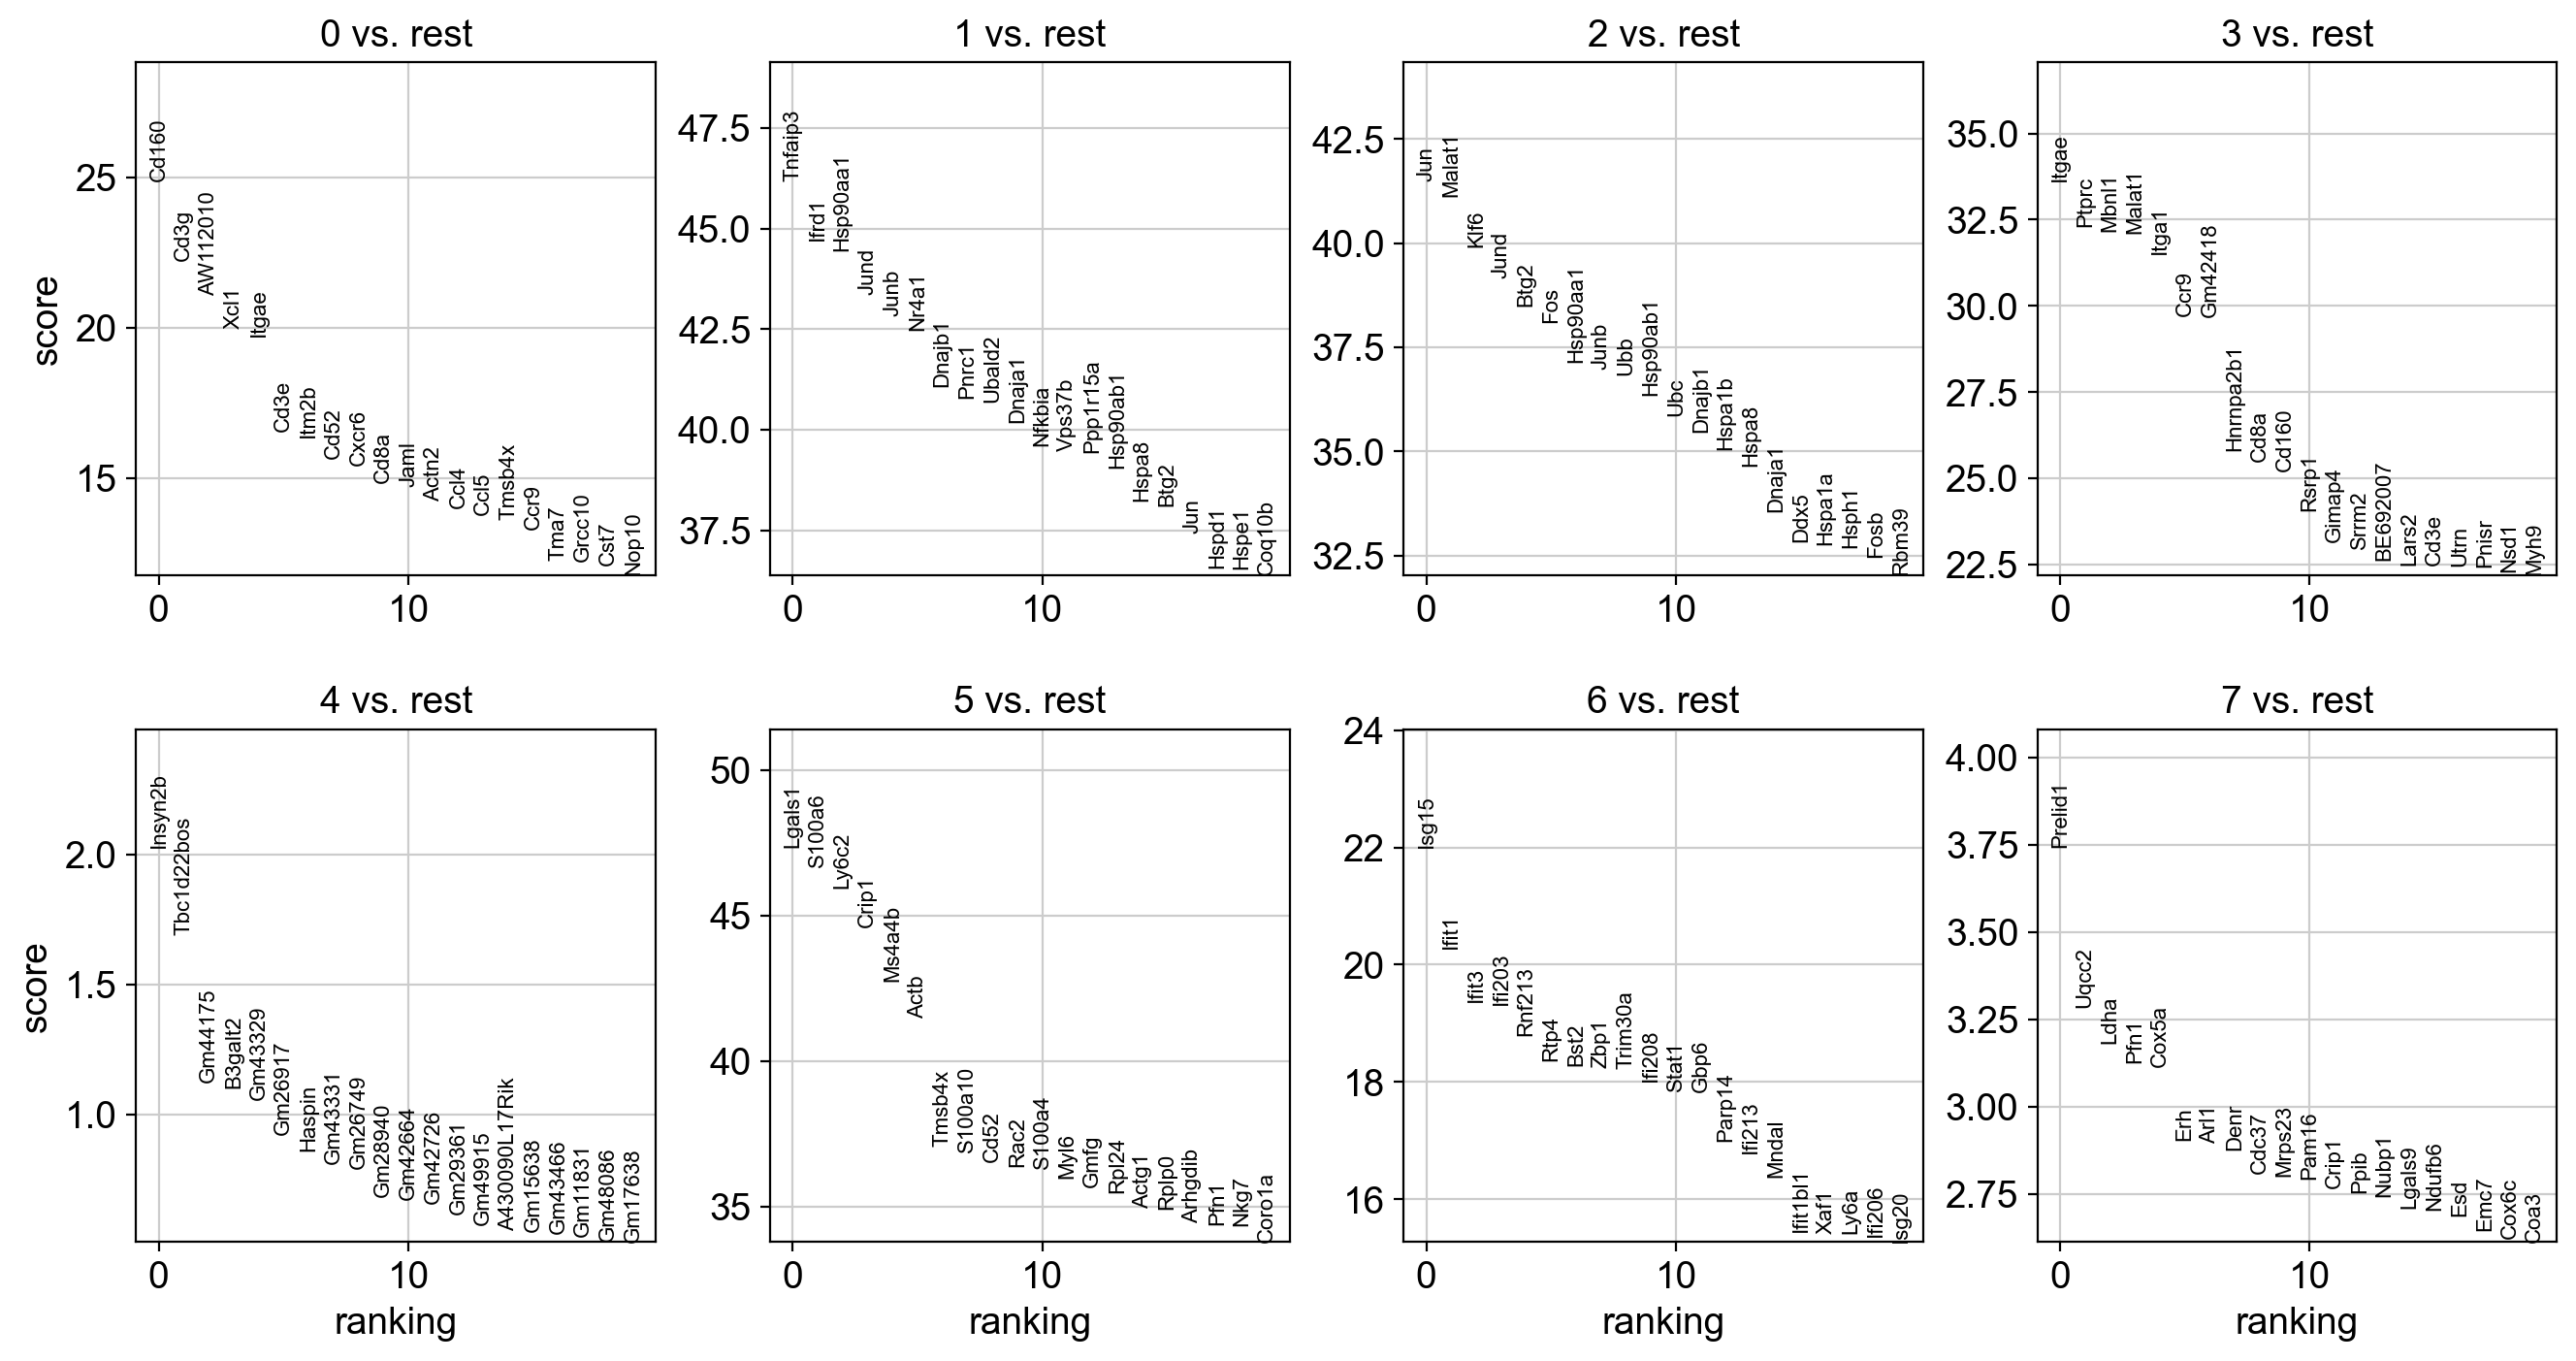

In [4]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden_0_5",
    method="wilcoxon",
    use_raw=True,
)

sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)


In [5]:
markers_df = sc.get.rank_genes_groups_df(adata, group=None)

marker_file = RESULTS_DIR / "04_cluster_markers_leiden_0_5.xlsx"
marker_file.parent.mkdir(parents=True, exist_ok=True)
markers_df.to_excel(marker_file, index=False)

print("Saved:", marker_file)


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/04_cluster_markers_leiden_0_5.xlsx


## Confirm CD8 Markers

Use a small marker panel to confirm the expected CD8 T-cell identity. `Cd8a` and `Cd8b1` are the main CD8 markers; the additional genes help review T-cell state and tissue-residency patterns across clusters.

In [6]:
cd8_genes = ["Cd8a", "Cd8b1"]
t_cell_genes = ["Cd3d", "Cd3e", "Trac"]
context_genes = ["Nkg7", "Gzmb", "Prf1", "Ifng", "Tcf7", "Lef1", "Cxcr6", "Itgae", "Cd69"]

marker_genes = t_cell_genes + cd8_genes + context_genes
var_names = adata.raw.var_names if adata.raw is not None else adata.var_names

genes_present = [gene for gene in marker_genes if gene in var_names]
genes_missing = [gene for gene in marker_genes if gene not in var_names]

print("Present:", genes_present)
print("Missing:", genes_missing)


Present: ['Cd3d', 'Cd3e', 'Trac', 'Cd8a', 'Cd8b1', 'Nkg7', 'Gzmb', 'Prf1', 'Ifng', 'Tcf7', 'Lef1', 'Cxcr6', 'Itgae', 'Cd69']
Missing: []


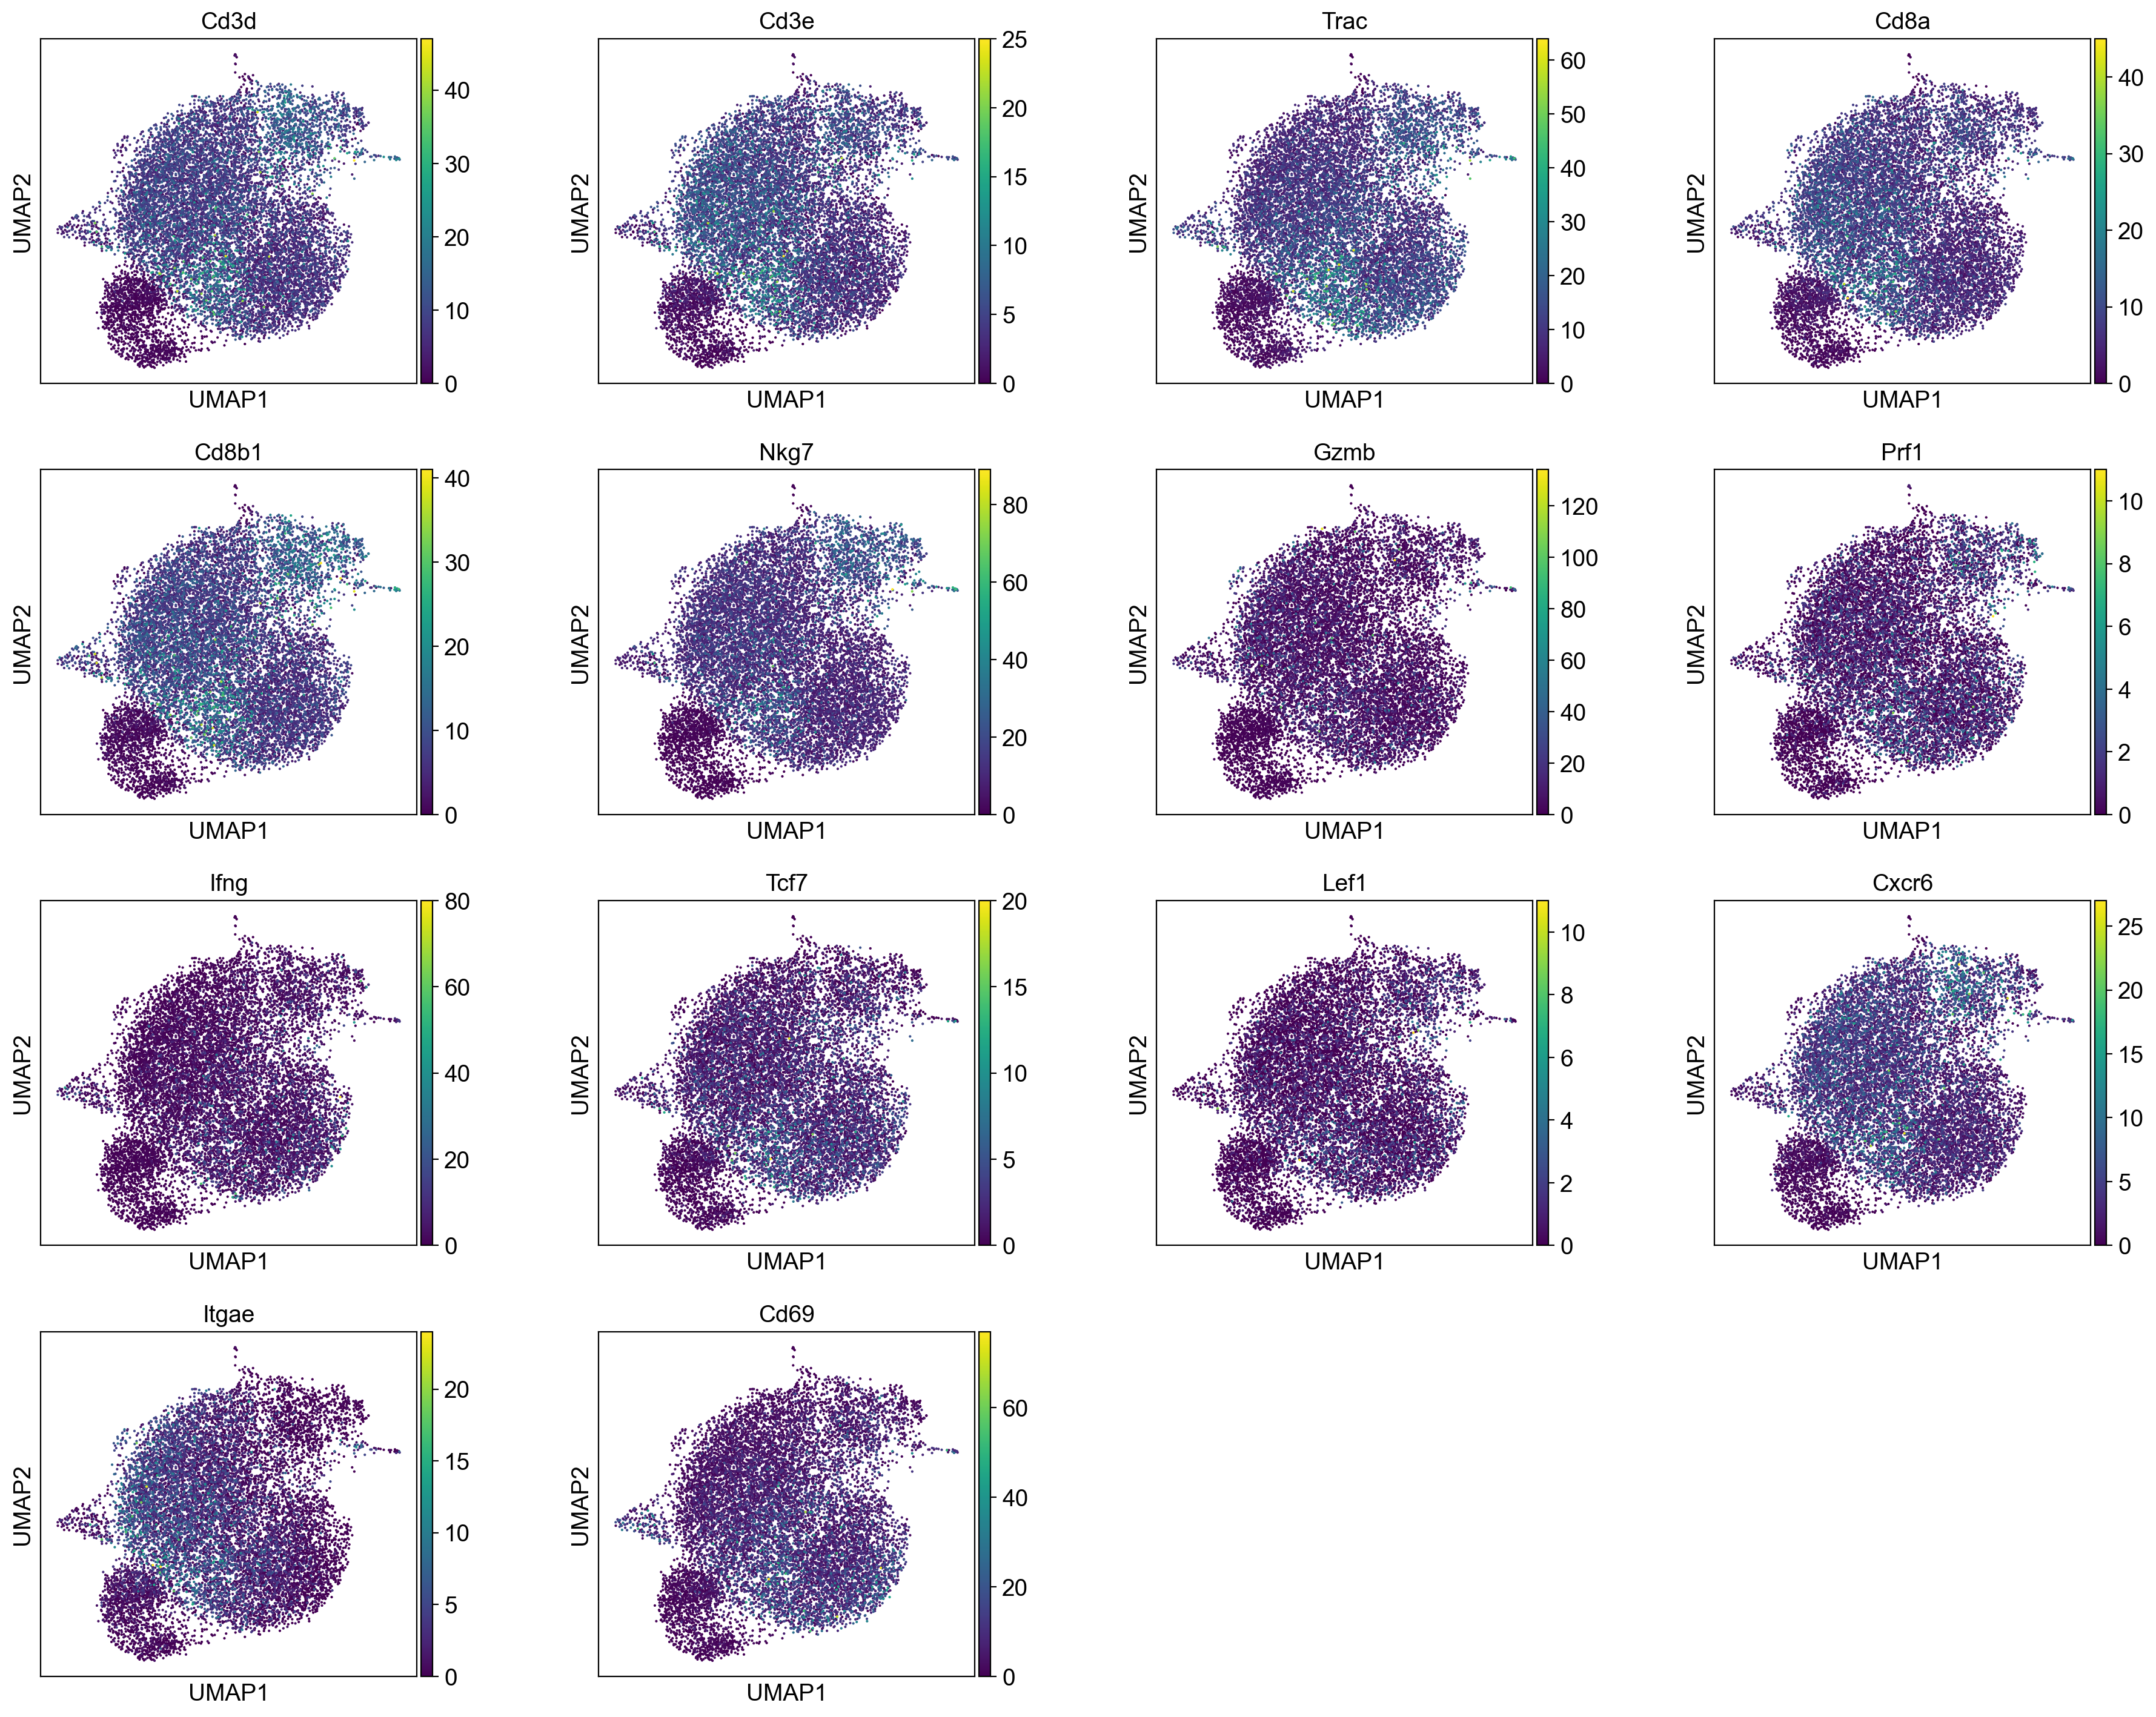

In [7]:
sc.pl.umap(
    adata,
    color=genes_present,
    use_raw=True,
    wspace=0.35,
)


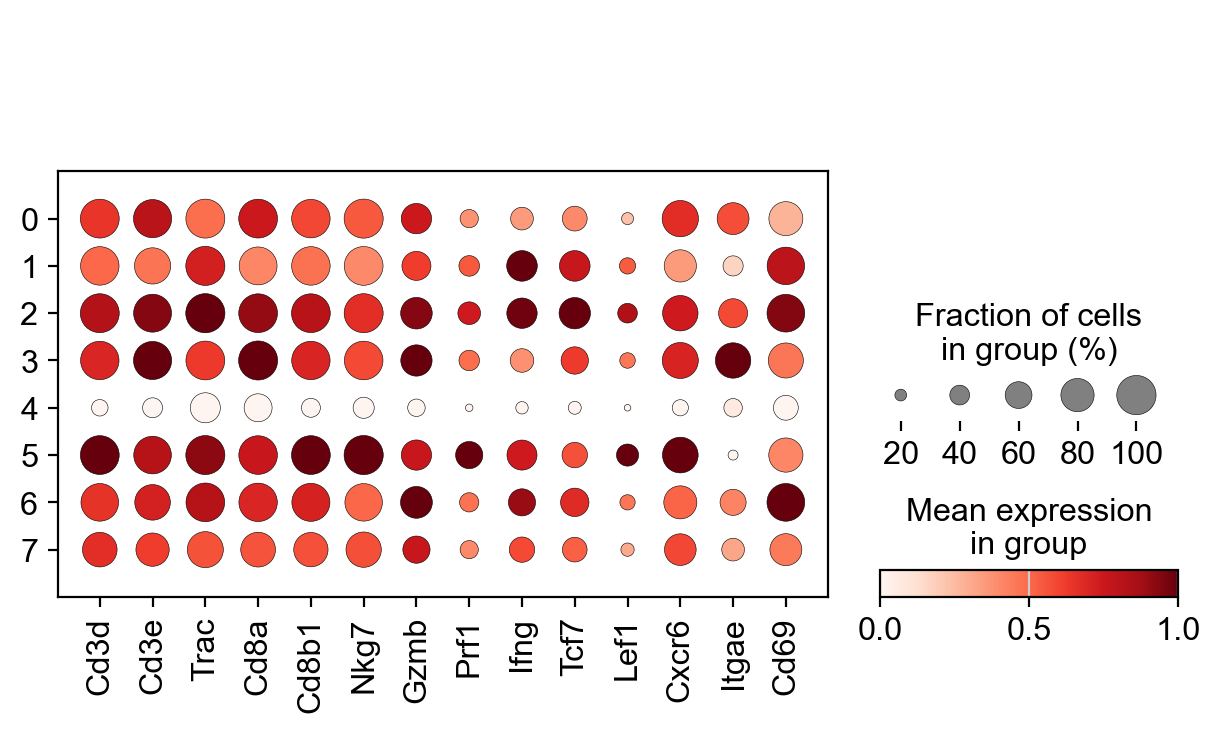

In [8]:
sc.pl.dotplot(
    adata,
    var_names=genes_present,
    groupby="leiden_0_5",
    use_raw=True,
    standard_scale="var",
)


## Annotate CD8 T Cells

The whole dataset is CD8 T cells. The cluster-level marker table below is for review only; all cells are annotated as `CD8 T cell`.

In [9]:
score_genes = [gene for gene in cd8_genes + t_cell_genes if gene in var_names]
expr = sc.get.obs_df(adata, keys=score_genes, use_raw=True)
expr["leiden_0_5"] = adata.obs["leiden_0_5"].values

cluster_scores = expr.groupby("leiden_0_5", observed=True).mean()
cluster_scores["cd8_score"] = cluster_scores[[gene for gene in cd8_genes if gene in cluster_scores]].mean(axis=1)
cluster_scores["t_cell_score"] = cluster_scores[[gene for gene in t_cell_genes if gene in cluster_scores]].mean(axis=1)
cluster_scores["n_cells"] = adata.obs["leiden_0_5"].value_counts().sort_index().reindex(cluster_scores.index).astype(int)

cluster_scores.sort_index()


,Cd8a,Cd8b1,Cd3d,Cd3e,Trac,cd8_score,t_cell_score,n_cells
leiden_0_5,,,,,,,,
0,6.332415,6.056149,6.864623,4.100930,7.206683,6.194282,6.057412,2903
1,4.071429,4.991858,5.435603,2.632864,9.903035,4.531643,5.990501,2702
2,7.383550,8.115151,8.647619,4.650650,13.038961,7.749351,8.779077,2310
3,7.995255,7.130206,7.391671,4.907222,8.849236,7.562731,7.049376,1897
4,1.338001,0.593889,0.531509,0.641630,1.705283,0.965945,0.959474,1571
5,6.408563,9.850508,10.295356,4.153121,12.158200,8.129536,8.868893,1378
6,6.000000,7.193133,6.922747,3.708154,11.030043,6.596566,7.220315,233
7,5.066038,5.863207,7.080189,3.301887,8.113208,5.464622,6.165094,212


In [10]:
adata.obs["cell_type_manual"] = "CD8 T cell"
adata.obs["cd8_subset"] = "CD8 T cell"

adata.obs["cd8_subset"].value_counts()


cd8_subset
CD8 T cell    13206
Name: count, dtype: int64

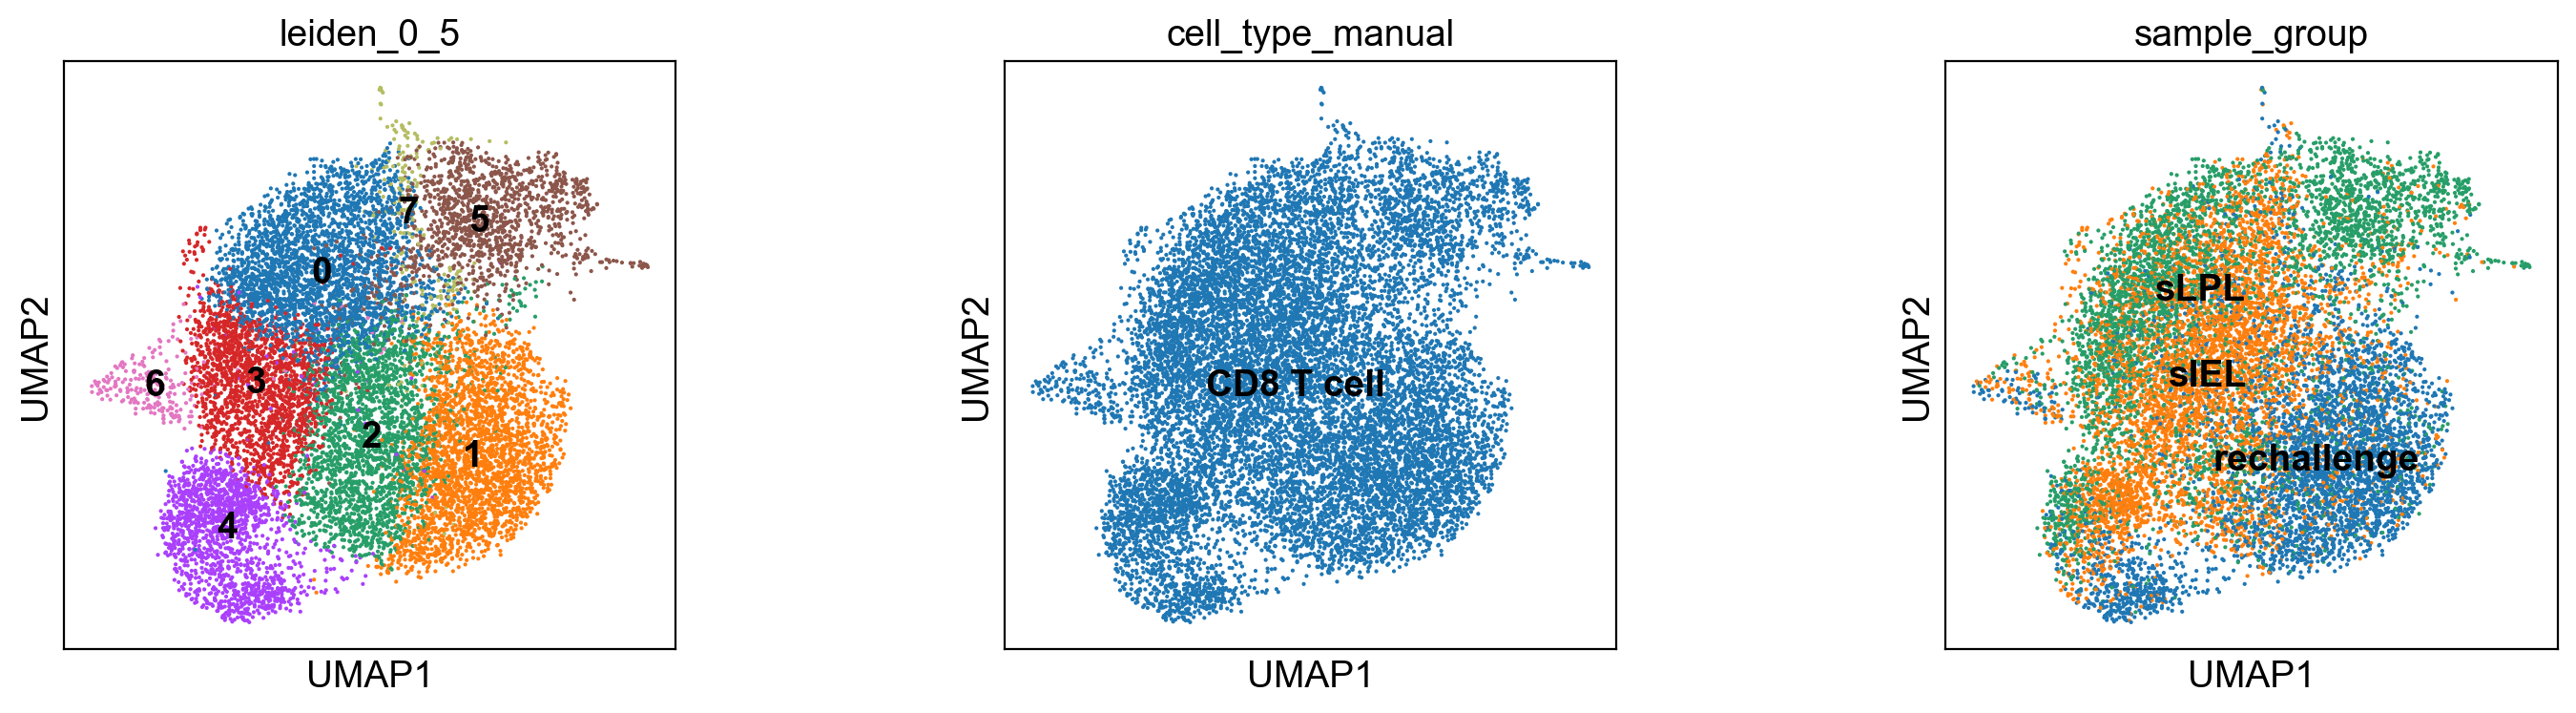

In [11]:
sc.pl.umap(
    adata,
    color=["leiden_0_5", "cell_type_manual", "sample_group"],
    legend_loc="on data",
    wspace=0.4,
)


## Save Annotated Objects

Save the annotated full object. Because the whole dataset is CD8 T cells, the CD8 subset object contains the same cells and is saved only as a convenient downstream input.

In [12]:
summary_file = RESULTS_DIR / "04_cd8_cluster_scores.csv"
cluster_scores.reset_index().to_csv(summary_file, index=False)
print("Saved:", summary_file)


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/04_cd8_cluster_scores.csv


In [13]:
annotated_file = INTERMEDIATE_DIR / "04_cell_annotation.h5ad"
cd8_subset_file = INTERMEDIATE_DIR / "04_cd8_subset.h5ad"

adata.write_h5ad(annotated_file)

cd8_subset = adata[adata.obs["cd8_subset"].eq("CD8 T cell")].copy()
cd8_subset.write_h5ad(cd8_subset_file)

print("Saved:", annotated_file)
print("Saved:", cd8_subset_file)
print(cd8_subset)


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/04_cell_annotation.h5ad
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/objects/04_cd8_subset.h5ad
AnnData object with n_obs × n_vars = 13206 × 16263
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'hash_id', 'hto_max', 'hto_second', 'hto_top_to_second_ratio', 'hto_total', 'sample_group', 'man_2025_group', 'demux_call', 'hto_HT1', 'hto_HT2', 'hto_HT3', 'leiden_0_5', 'cell_type_manual', 'cd8_subset'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highl